In [1]:
import torch
from torch import nn

### Done after multihead attention layer

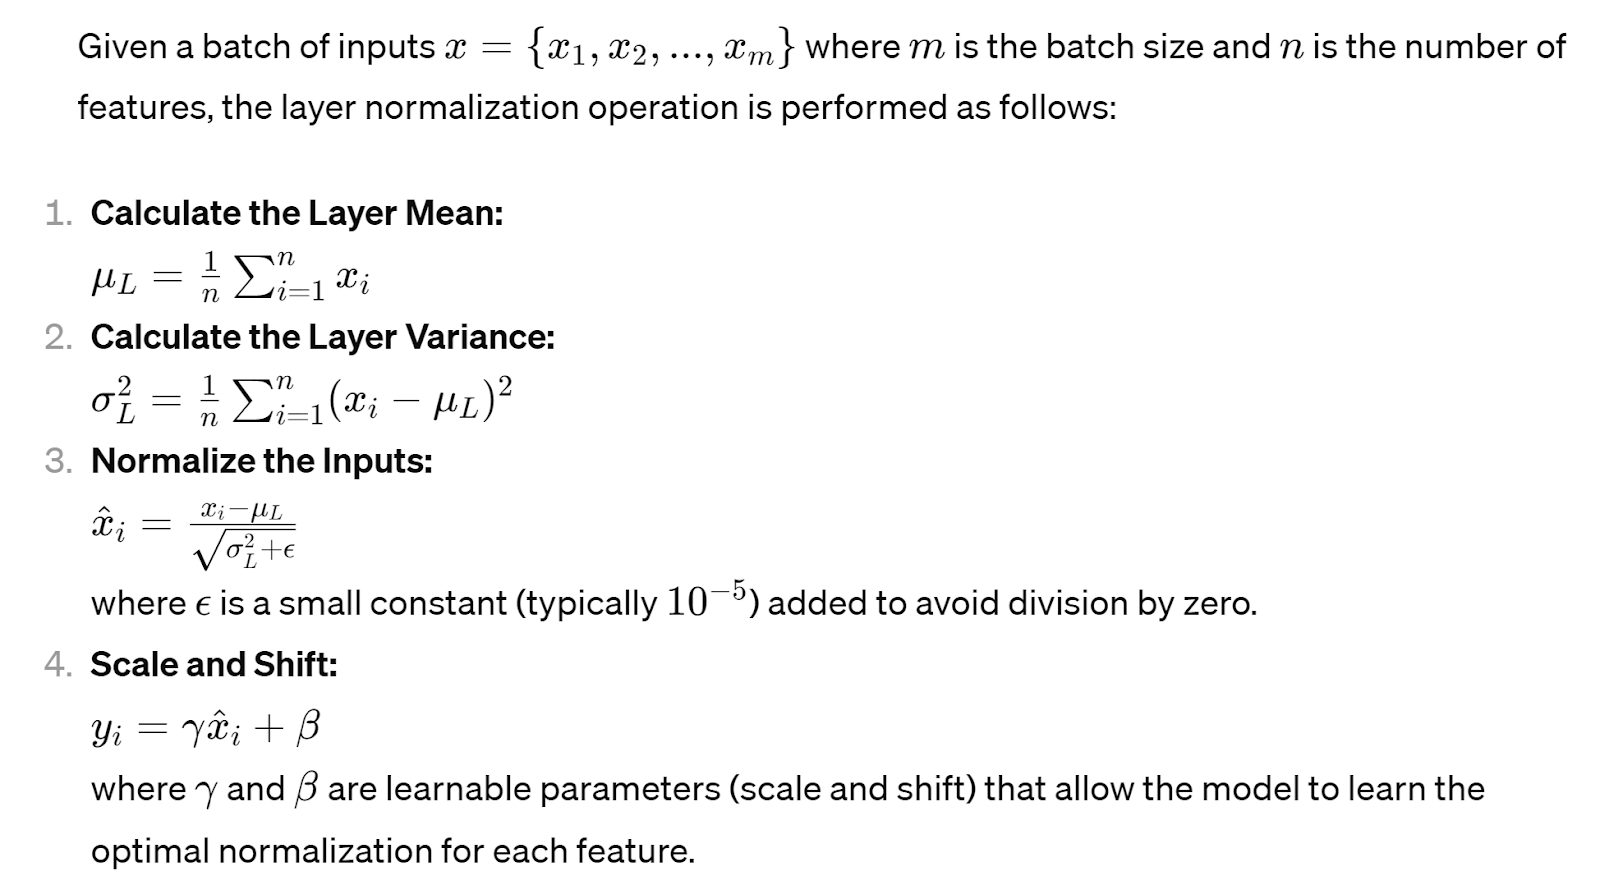

In [3]:
inputs = torch.Tensor([[[0.8, 0.3, 0.7], [0.4, 0.2 ,0.01]]])
#the layers we are normalizing

In [6]:
Batch, S, E = inputs.size()

reshaping the tensor so that normalization happens across the last two dimensions, and gamma/beta are created to match that shape for learnable scaling.

In [9]:
inputs = inputs.reshape(S, Batch, E)
inputs.size()

torch.Size([2, 1, 3])

In [11]:
#grabs the last 2 dimensions of a tensor's shape.
parameter_shape = inputs.size()[-2:]


In [12]:
gamma = nn.Parameter(torch.ones(parameter_shape))
beta =  nn.Parameter(torch.zeros(parameter_shape))

In [13]:
dims = []

for i in range(len(parameter_shape)):
    dims.append(-(i + 1))

In [14]:
dims

[-1, -2]

In [16]:
mean = inputs.mean(dim=dims, keepdim=True)
mean

tensor([[[0.6000]],

        [[0.2033]]])

In [17]:
mean.size()

torch.Size([2, 1, 1])

In [18]:
var = ((inputs - mean) ** 2).mean(dim=dims, keepdim=True)
epsilon = 1e-5
#epsilon so that we divide by std its not 0
std = (var + epsilon).sqrt()
std


tensor([[[0.2160]],

        [[0.1593]]])

In [19]:
y = (inputs - mean) / std
y


tensor([[[ 0.9257, -1.3886,  0.4629]],

        [[ 1.2348, -0.0209, -1.2139]]])

In [20]:
out = gamma * y + beta

In [21]:
out

tensor([[[ 0.9257, -1.3886,  0.4629]],

        [[ 1.2348, -0.0209, -1.2139]]], grad_fn=<AddBackward0>)